In [1]:
from toolbox import tissueSample
dir = "final/"
samples = {i:tissueSample.Sample.periodic_tissue(config_dir=dir,input_filename="{:07d}.sample.topo".format(i)) for i in range(21)}
for i, sample in samples.items():
    sample.sample_center_ = sample.cells_[211].center_
    sample.time_ = i
    sample.load_periodic_tissue_cell_properties()
    cell = sample.extract_cell(211)
    cell.dump_vtk(dir+"{:07d}.fixed.vtk".format(i))

In [2]:
def load_shape_index_change(sample0:tissueSample.Sample,sample1:tissueSample.Sample):
    cellIDs = []
    for cellID,cell in sample0.cells_.items():
        if cell.crossBoundary_:
            continue
        if cellID not in sample1.cells_:
            continue
        if sample1.cells_[cellID].crossBoundary_:
            continue
        cellIDs.append(cellID)
    diff_shape_indices = {cellID:sample1.cells_[cellID].shape_index_-sample0.cells_[cellID].shape_index_ for cellID in cellIDs}
    for cellID,change in diff_shape_indices.items():
        sample1.cells_[cellID].shape_index_change_ = change

for i in range(1,21):
    load_shape_index_change(samples[i-1],samples[i])

In [3]:
from toolbox import functions
# def create_change_vtk(sample0:tissueSample.Sample,sample1:tissueSample.Sample,filename:str):
def create_change_vtk(sample:tissueSample.Sample,filename:str):

    vertices = []
    total_polygons = 0
    total_polygon_data_points = 0
    for polygonID,polygon in sample.polygons_.items():
        if polygon.crossBoundary_:
            continue
        total_polygons += 1
        total_polygon_data_points += len(polygon.vertices_) + 1
        for vertex in polygon.vertices_:
            vertices.append(vertex)
    vertices = list(set(vertices))
    v_map = functions.mapmaker(vertices)
    with open("{}".format(filename),"w") as f:
        f.write("# vtk DataFile Version 2.0\n")
        f.write("polydata\n")
        f.write("ASCII\n")
        f.write("DATASET POLYDATA\n")
        f.write("POINTS {} double\n".format(len(vertices)))
        for vertexID in vertices:
            for i in range(3):
                f.write("{} ".format(sample.vertices_[vertexID].position_[i]))
            f.write("\n")
        f.write("POLYGONS {} {}\n".format(total_polygons,total_polygon_data_points))
        for polygonID,polygon in sample.polygons_.items():
            if polygon.crossBoundary_:
                continue
            f.write("{} ".format(len(polygon.vertices_)))
            for vertexID in polygon.vertices_:
                f.write("{} ".format(v_map[vertexID]))
            f.write("\n")
        f.write("CELL_DATA {}\n".format(total_polygons))
        # f.write("SCALARS is_fixed double\n")
        # f.write("LOOKUP_TABLE default\n")
        # for polygonID,polygon in sample.polygons_.items():
        #     if polygon.crossBoundary_:
        #         continue
        #     if polygon.is_fixed_:
        #         f.write("1\n")
        #     else:
        #         f.write("0\n")
        # f.write("SCALARS vol_changes double\n")
        # f.write("LOOKUP_TABLE default\n")
        # for polygonID,polygon in sample.polygons_.items():
        #     if polygon.crossBoundary_:
        #         continue
        #     for cellID,cell in sample.cells_.items():
        #         if polygonID in cell.polygons_:
        #             if diff_volumes[cellID] is None:
        #                 f.write("0\n")
        #                 break
        #             else:
        #                 f.write("{:.14f}\n".format(diff_volumes[cellID]))
        #                 break
        f.write("SCALARS shape_index_changes double\n")
        f.write("LOOKUP_TABLE default\n")
        for polygonID,polygon in sample.polygons_.items():
            if polygon.crossBoundary_:
                continue
            for cellID,cell in sample.cells_.items():
                if polygonID in cell.polygons_:
                    if cell.shape_index_change_ is None:
                        f.write("0\n")
                        break
                    else:
                        f.write("{:.14f}\n".format(cell.shape_index_change_))
                        break

for i in range(1,21):
    create_change_vtk(samples[i],dir+"{:07d}.change.vtk".format(i))

In [13]:
from toolbox import tissueCrossSection
import numpy as np
for i in range(10,21):
    tissueCrossSection.makeSampleCrossSection(samples[i],normal=np.array([1,1,1])/np.sqrt(3))

IndexError: list index out of range

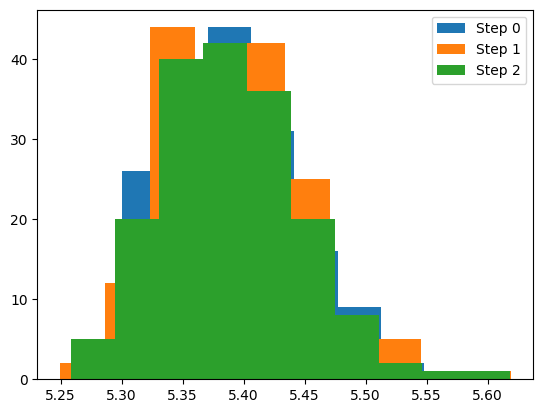

In [4]:
from toolbox import training
import matplotlib.pyplot as plt
for i in range(3):
    tr = training.Training.from_config(config_dir= "7_2/", input_filename="{:07d}.sample.topo".format(i))
    tr._config.load_periodic_tissue_cell_properties()
    # for cellID,cell in tr._config.cells_.items():
    #     print(cellID)
    #     print(cell.shape_index_)
    shape_indices = []
    for cellID,cell in tr._config.cells_.items():
        if cell.shape_index_ is not None:
            shape_indices.append(cell.shape_index_)
    plt.hist(shape_indices, bins=10, label = "Step {}".format(i))
plt.legend()
    # tr.write_periodic_vtk(filename="{:07d}.sample.vtk".format(i))

In [ ]:
# Single fixed cell pulse drive
from toolbox import training
tr = training.Training.from_config(config_dir = "7_6/", input_filename = "minimized.txt")
tr.set_expansion_factor(0.25)
tr.pick_fixed_cell()
tr.pulse_drive(n_iterations = 10)


Initialization start ...
Number of vertices: 2044
Maximum vertex ID: 6125
Number of edges: 4088
Maximum edge ID: 16994
Number of polygons: 2387
Maximum polygon ID: 3306
Number of cells: 343
Maximum cell ID: 342
Number of polygons with two neighboring cells: 2387/2387
time: 0 ~ 2000 ~ 0.005 ~ 0.05
dump: vtk 100
log: 100
s0: 5.2
Lth: 0.02 verbose: 0
temperature: 0.0001
kv: 1
box: 7 7 7 periodic boundary condition: 1 1 1
Initialization start ...
Fixing vertices for the following cells: 
40
Initial F_rms: 0.0260742

Starting overdamped motion...
Real time elapsed: Rte

Time        Rte         Volume      I->H        H->I        E_volume    E_interface Energy      F_rms       
0.00        0.002       343.000     0           0           0.189543    12.399521   12.589064   0.026074    
100.00      40.380      343.000     6           5           0.132618    12.575743   12.708361   0.017137    
200.00      41.159      343.000     1           3           0.127595    12.488980   12.616575   0.016

In [2]:
from toolbox import training
tr = training.Training.from_config(config_dir = "7_5/", input_filename = "minimized.txt")
# tr.set_stepsize(0.1)
tr.set_expansion_factor(0.25)
tr.pick_fixed_pair()
# tr.pick_fixed_cell()
tr.pulse_drive(n_iterations = 10)
# tr.set_minimum_separation(3.3)
# # tr.load_fixed_cells()
# tr.pick_fixed_pair()
# tr.run()
# # tr.minimize_config()

Initialization start ...
Number of vertices: 2048
Maximum vertex ID: 6657
Number of edges: 4096
Maximum edge ID: 18694
Number of polygons: 2391
Maximum polygon ID: 3414
Number of cells: 343
Maximum cell ID: 342
Number of polygons with two neighboring cells: 2391/2391
time: 0 ~ 2000 ~ 0.005 ~ 0.05
dump: vtk 100
log: 100
s0: 5.2
Lth: 0.02 verbose: 0
temperature: 0.0001
kv: 1
box: 7 7 7 periodic boundary condition: 1 1 1
Initialization start ...
Fixing vertices for the following cells: 
170
236
Initial F_rms: 0.0224554

Starting overdamped motion...
Real time elapsed: Rte

Time        Rte         Volume      I->H        H->I        E_volume    E_interface Energy      F_rms       
0.00        0.002       343.000     0           0           0.161596    11.364474   11.526070   0.022455    
100.00      39.927      343.000     0           0           0.116741    11.639310   11.756051   0.016878    

   Zero reconnections since the previous log dump.
   Terminating overdamped motion and proceed

(array([ 1.,  1.,  0.,  0.,  1.,  1.,  1.,  3.,  1.,  3.,  1.,  9.,  5.,
         5., 11.,  7.,  7.,  9.,  8.,  9., 10.,  6.,  4.,  7.,  6.,  6.,
         3.,  5.,  2.,  4.,  7.,  4.,  6.,  4.,  4.,  3.,  2.,  3.,  2.,
         0.,  2.,  1.,  2.,  0.,  2.,  0.,  1.,  1.,  0.,  1.]),
 array([5.24934373, 5.2551096 , 5.26087547, 5.26664134, 5.27240721,
        5.27817308, 5.28393894, 5.28970481, 5.29547068, 5.30123655,
        5.30700242, 5.31276829, 5.31853415, 5.32430002, 5.33006589,
        5.33583176, 5.34159763, 5.3473635 , 5.35312937, 5.35889523,
        5.3646611 , 5.37042697, 5.37619284, 5.38195871, 5.38772458,
        5.39349044, 5.39925631, 5.40502218, 5.41078805, 5.41655392,
        5.42231979, 5.42808566, 5.43385152, 5.43961739, 5.44538326,
        5.45114913, 5.456915  , 5.46268087, 5.46844673, 5.4742126 ,
        5.47997847, 5.48574434, 5.49151021, 5.49727608, 5.50304195,
        5.50880781, 5.51457368, 5.52033955, 5.52610542, 5.53187129,
        5.53763716]),
 <BarContainer

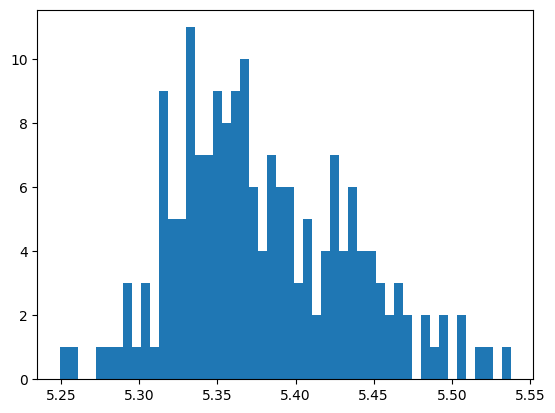

In [1]:
from toolbox import tissueSample

sample = tissueSample.Sample.periodic_tissue(config_dir = "7_1/", input_filename = "minimized.txt")
sample.calculate_COM_polygon_centers()
sample.calculate_cell_volumes()
sample.calculate_polygon_areas()
sample.calculate_cell_surface_areas()
sample.calculate_cell_shape_indices()

shape_indices = []
for cellID, cell in sample.cells_.items():
    if not cell.crossBoundary_:
        shape_indices.append(cell.shape_index_)

import matplotlib.pyplot as plt
plt.hist(shape_indices, bins = 50)


In [ ]:
for

In [ ]:
from toolbox import training
tr = training.Training.from_config(config_dir = "test10/", input_filename = "initial.topo")
tr.set_stepsize(0.05)
tr.set_minimum_separation(2.8)
# tr.pick_fixed_cells()
tr.load_fixed_cells()
tr.run()

Initialization start ...
Number of vertices: 3049
Maximum vertex ID: 28123
Number of edges: 6098
Maximum edge ID: 86082
Number of polygons: 3561
Maximum polygon ID: 8739
Number of cells: 512
Maximum cell ID: 511
Number of polygons with two neighboring cells: 3561/3561
time: 0 ~ 2000 ~ 0.005 ~ 0.05
dump: vtk 100
log: 100
s0: 5.2
Lth: 0.02 verbose: 0
temperature: 0.0001
kv: 1
box: 8 8 8 periodic boundary condition: 1 1 1
Initialization start ...
Fixing vertices for cells: 
316
489
Initial F_rms: 9.87674e-08
   Minimization terminated:
   Input is already minimized at FIRE_equilibrium_tolerance: 1e-07
Current separation: 4.000000000000009
Initialization start ...
Number of vertices: 3049
Maximum vertex ID: 28123
Number of edges: 6098
Maximum edge ID: 86082
Number of polygons: 3561
Maximum polygon ID: 8739
Number of cells: 512
Maximum cell ID: 511
Number of polygons with two neighboring cells: 3561/3561
time: 0 ~ 2000 ~ 0.005 ~ 0.05
dump: vtk 100
log: 100
s0: 5.2
Lth: 0.02 verbose: 0
tempe